In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

# Настройка качественного отображения графиков в Colab
%config InlineBackend.figure_format = 'retina'

In [2]:
# Параметры системы
l1, l2 = 1.0, 0.15
m_true = np.array([5.0, 1.5, 0.5])
B_true = np.array([1.2, 0.8, 2.4])
D_true = np.array([0.6, 0.4, 1.1])
g = 9.81

T_end = 2.0

In [3]:
# Целевая траектория (qd, dqd, ddqd)
def get_target(t):
    c = [
        [np.pi/4, 0, 0, 25*np.pi/48, -25*np.pi/64, 5*np.pi/64],
        [0.1, 0, 0, 0.25, -0.1875, 0.0375],
        [np.pi/2, 0, 0, -5*np.pi/12, 5*np.pi/16, -np.pi/16]
    ]
    qd, dqd, ddqd = [], [], []
    for i in range(3):
        qd.append(c[i][0] + c[i][3]*t**3 + c[i][4]*t**4 + c[i][5]*t**5)
        dqd.append(3*c[i][3]*t**2 + 4*c[i][4]*t**3 + 5*c[i][5]*t**4)
        ddqd.append(6*c[i][3]*t + 12*c[i][4]*t**2 + 20*c[i][5]*t**3)
    return np.array(qd), np.array(dqd), np.array(ddqd)

def get_dynamics(q, dq, m, B_diag, D_diag):
    q1, q2, q3 = q
    dq1, dq2, dq3 = dq
    m2, m3 = m[1], m[2]

    M = np.zeros((3, 3))
    M[0, 0] = m2*q2**2 + m3*(q2 + l2*np.cos(q3))**2
    M[1, 1] = m2 + m3
    M[1, 2] = M[2, 1] = -m3*l2*np.sin(q3)
    M[2, 2] = m3*l2**2

    C_vec = np.array([
        2*(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1*dq2 - 2*m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1*dq3,
        -(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1**2 - m3*l2*dq3**2*np.cos(q3),
        m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1**2
    ])

    G_vec = np.array([0, 0, m3*g*l2*np.cos(q3)])
    Friction = B_diag * dq + D_diag * np.sign(dq)

    return M, C_vec, G_vec, Friction

def get_regressor(q, dq, dqr, ddqr):
    q1, q2, q3 = q
    dq1, dq2, dq3 = dq
    Y = np.zeros((3, 9))

    # Индекс 0: m1
    Y[:, 0] = 0

    # Индекс 1: m2
    Y[0, 1] = q2**2 * ddqr[0] + 2*q2*dq2*dqr[0]
    Y[1, 1] = ddqr[1] - q2*dq1*dqr[0]

    # Индекс 2: m3
    Y[0, 2] = (q2 + l2*np.cos(q3))**2 * ddqr[0] + 2*(q2 + l2*np.cos(q3))*(dq2 - l2*np.sin(q3)*dq3)*dqr[0]
    Y[1, 2] = ddqr[1] - l2*np.sin(q3)*ddqr[2] - (q2 + l2*np.cos(q3))*dq1*dqr[0] - l2*np.cos(q3)*dq3*dqr[2]
    Y[2, 2] = -l2*np.sin(q3)*ddqr[1] + l2**2*ddqr[2] + l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1*dqr[0] + g*l2*np.cos(q3)

    # Индексы 3-5: B (вязкое трение)
    Y[0, 3], Y[1, 4], Y[2, 5] = dq1, dq2, dq3

    # Индексы 6-8: D (сухое трение)
    Y[0, 6], Y[1, 7], Y[2, 8] = np.sign(dq1), np.sign(dq2), np.sign(dq3)

    return Y

def robot_ode(t, state):
    q = state[0:3]
    dq = state[3:6]
    theta_hat = state[6:15]

    qd, dqd, ddqd = get_target(t)
    e, de = qd - q, dqd - dq
    Lambda, Ks = np.diag([10, 10, 10]), np.diag([60, 60, 60])
    s = de + Lambda @ e
    dqr, ddqr = dqd + Lambda @ e, ddqd + Lambda @ de

    Y = get_regressor(q, dq, dqr, ddqr)

    Gamma = np.diag([0.0, 5.0, 5.0, 10.0, 10.0, 10.0, 5.0, 5.0, 5.0])
    d_theta_hat = Gamma @ Y.T @ s

    tau = Y @ theta_hat + Ks @ s

    M, C, G, F = get_dynamics(q, dq, m_true, B_true, D_true)
    ddq = np.linalg.solve(M, tau - C - G - F)

    return np.concatenate((dq, ddq, d_theta_hat))

# Моделирование
initial_theta = np.array([4.0, 1.0, 0.3, 0.5, 0.5, 1.0, 0.2, 0.2, 0.5])
y0 = np.concatenate(([np.pi/4, 0.1, np.pi/2], [0,0,0], initial_theta))
sol = solve_ivp(robot_ode, [0, T_end], y0, t_eval=np.linspace(0, T_end, 500), method='RK45')


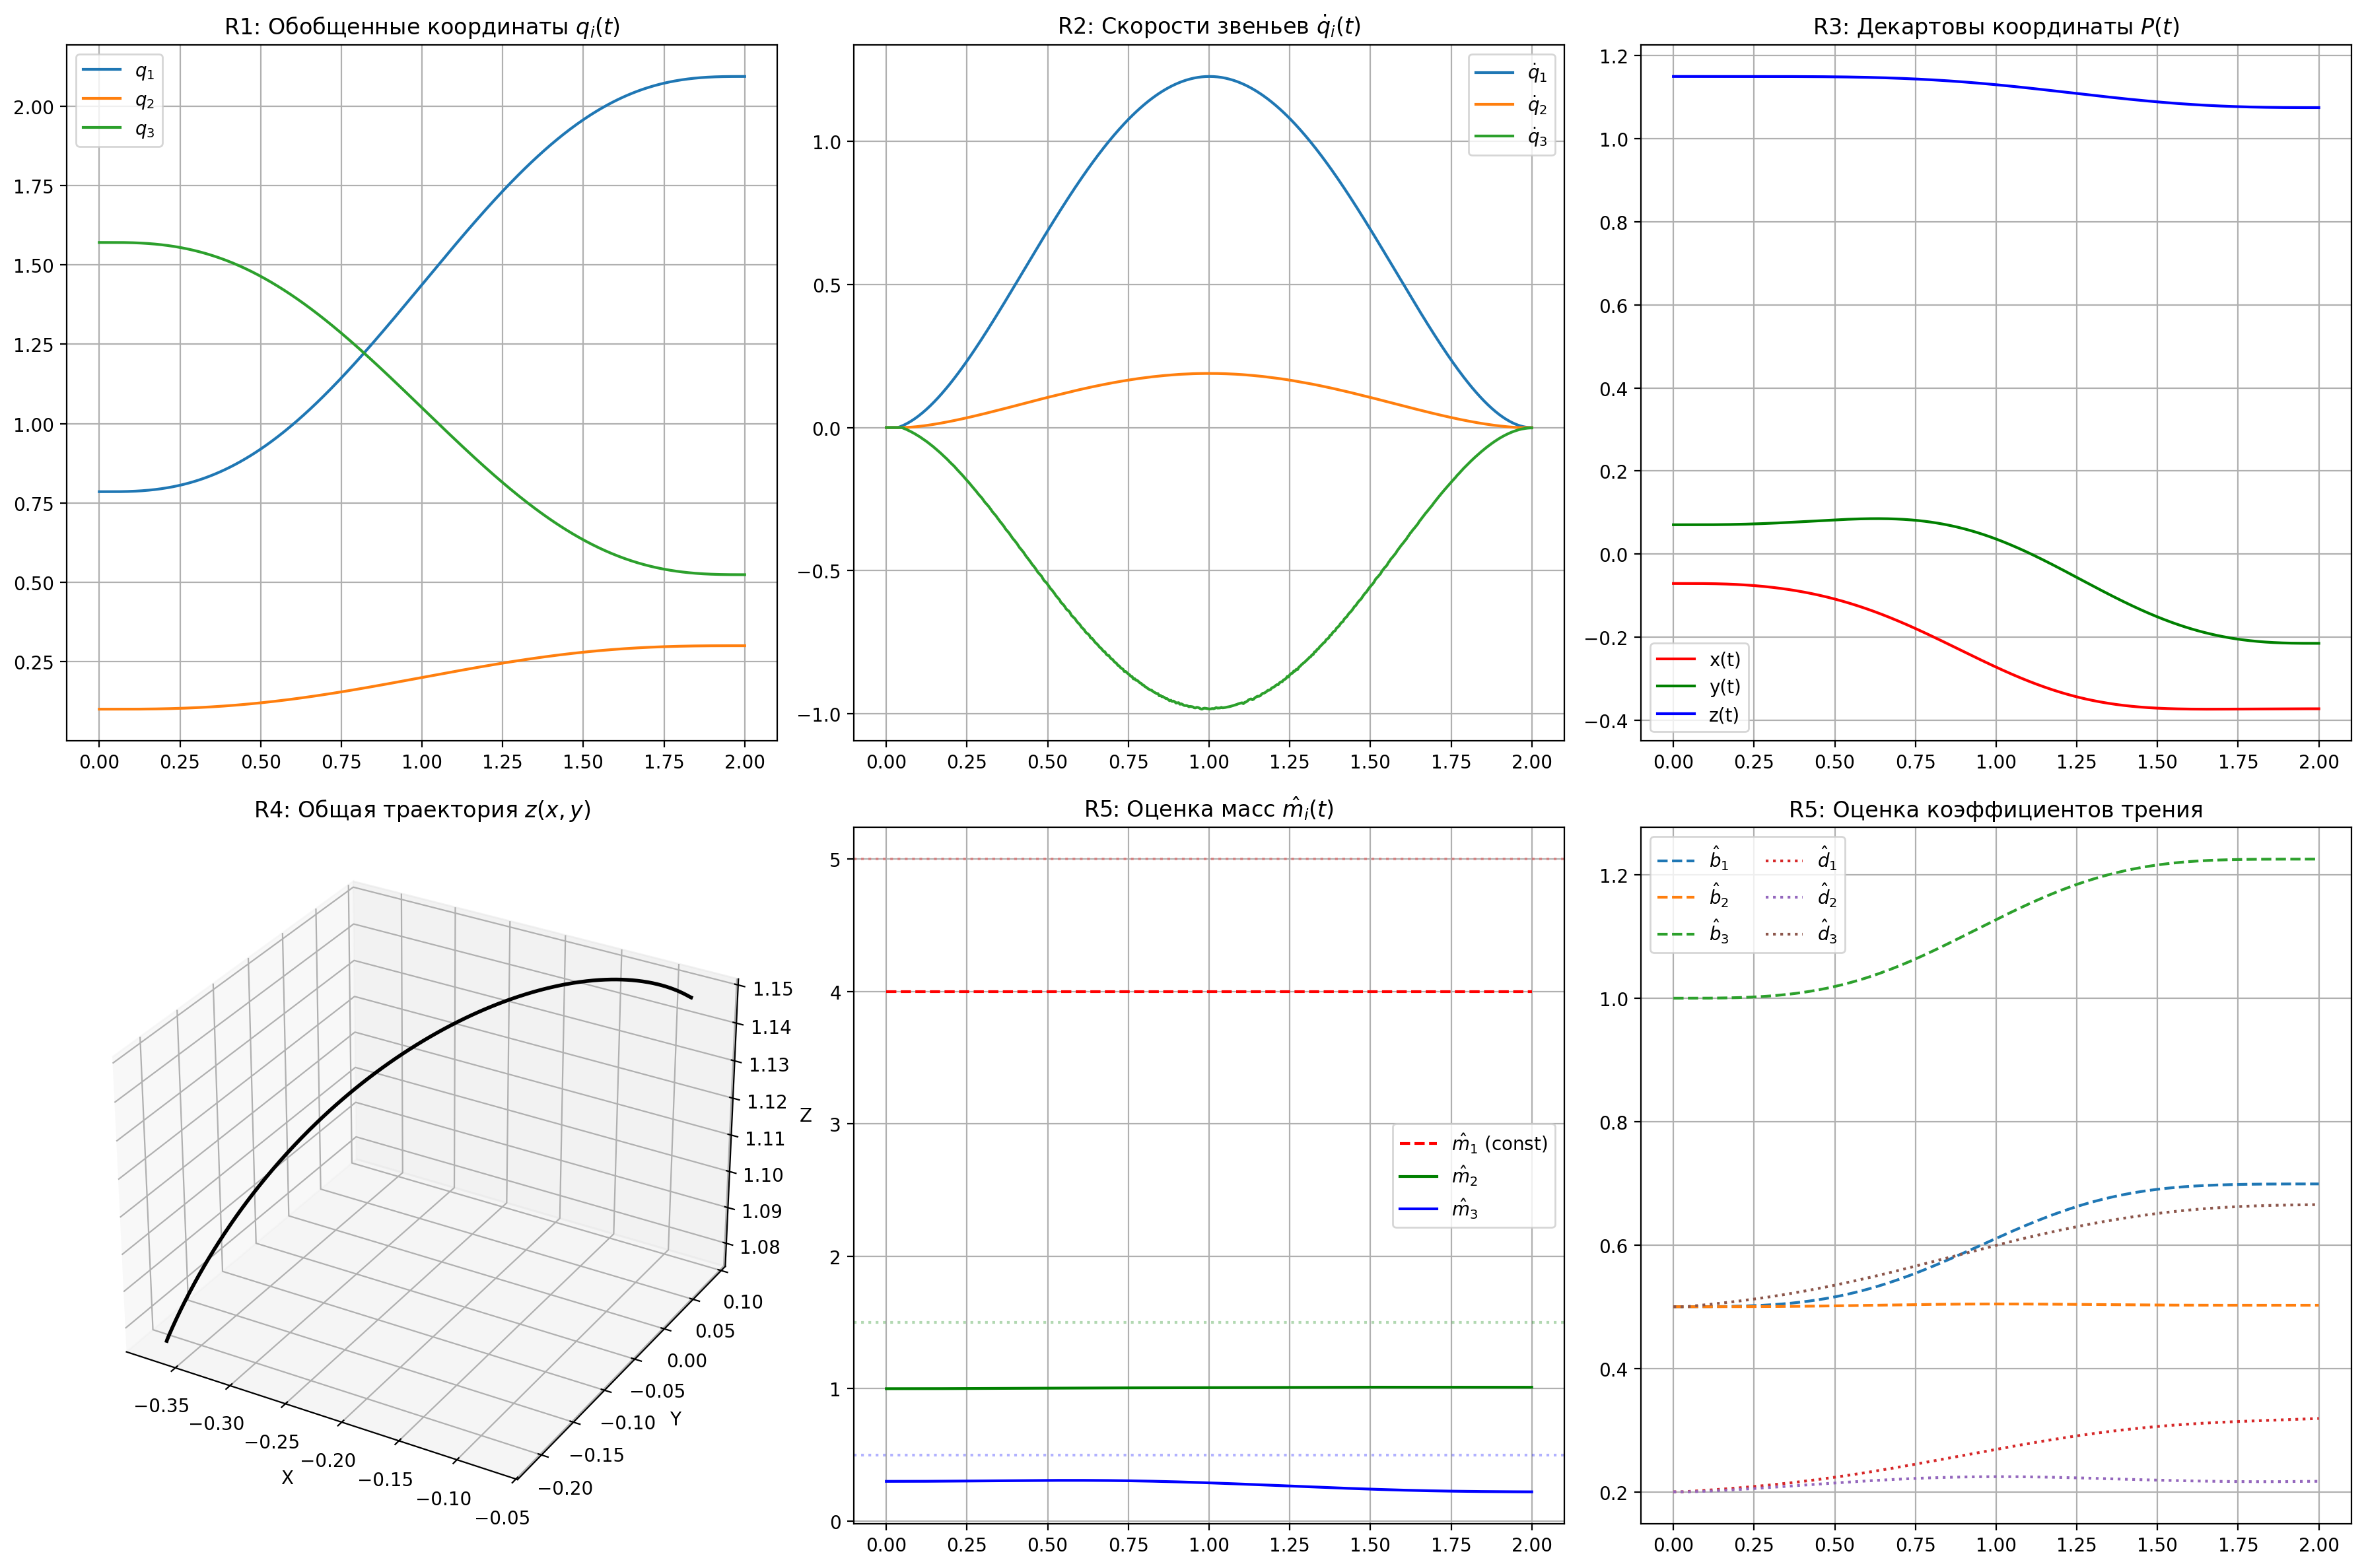

In [4]:
# Визуализация
t_plot = sol.t
q_plot = sol.y[0:3].T
dq_plot = sol.y[3:6].T
theta_plot = sol.y[6:15].T

def fk(qi):
    x = -(l2 * np.cos(qi[2]) + qi[1]) * np.sin(qi[0])
    y = (l2 * np.cos(qi[2]) + qi[1]) * np.cos(qi[0])
    z = l1 + l2 * np.sin(qi[2])
    return [x, y, z]

p = np.array([fk(val) for val in q_plot])

fig = plt.figure(figsize=(18, 12))

# R1: Координаты
ax1 = fig.add_subplot(2, 3, 1)
labels = ['$q_1$', '$q_2$', '$q_3$']
for i in range(3): ax1.plot(t_plot, q_plot[:,i], label=labels[i])
ax1.set_title('R1: Обобщенные координаты $q_i(t)$'); ax1.legend(); ax1.grid(True)

# R2: Скорости
ax2 = fig.add_subplot(2, 3, 2)
v_labels = [r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{q}_3$']
for i in range(3): ax2.plot(t_plot, dq_plot[:,i], label=v_labels[i])
ax2.set_title(r'R2: Скорости звеньев $\dot{q}_i(t)$'); ax2.legend(); ax2.grid(True)

# R3: Декартовы координаты
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(t_plot, p[:,0], 'r', label='x(t)')
ax3.plot(t_plot, p[:,1], 'g', label='y(t)')
ax3.plot(t_plot, p[:,2], 'b', label='z(t)')
ax3.set_title('R3: Декартовы координаты $P(t)$'); ax3.legend(); ax3.grid(True)

# R4: 3D траектория
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot(p[:,0], p[:,1], p[:,2], 'black', lw=2)
ax4.set_xlabel('X'); ax4.set_ylabel('Y'); ax4.set_zlabel('Z')
ax4.set_title('R4: Общая траектория $z(x, y)$')

# R5: Оценка масс
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(t_plot, theta_plot[:, 0], 'r--', label=r'$\hat{m}_1$ (const)')
ax5.plot(t_plot, theta_plot[:, 1], 'g', label=r'$\hat{m}_2$')
ax5.plot(t_plot, theta_plot[:, 2], 'b', label=r'$\hat{m}_3$')
ax5.axhline(5.0, color='r', alpha=0.3, ls=':'); ax5.axhline(1.5, color='g', alpha=0.3, ls=':'); ax5.axhline(0.5, color='b', alpha=0.3, ls=':')
ax5.set_title(r'R5: Оценка масс $\hat{m}_i(t)$'); ax5.legend(); ax5.grid(True)

# R5: Оценка трения
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(t_plot, theta_plot[:, 3:6], '--', label=[r'$\hat{b}_1$', r'$\hat{b}_2$', r'$\hat{b}_3$'])
ax6.plot(t_plot, theta_plot[:, 6:9], ':', label=[r'$\hat{d}_1$', r'$\hat{d}_2$', r'$\hat{d}_3$'])
ax6.set_title('R5: Оценка коэффициентов трения'); ax6.legend(ncol=2); ax6.grid(True)

plt.tight_layout()
plt.show()